In [2]:
import pandas as pd
import numpy as np
import os, sys
from matplotlib import pyplot as plt
import pickle as pk


sys.path.append(os.path.abspath(os.path.join(os.path.dirname("../"), os.pardir)))
from customFunctions.utils import *

In [3]:
mithril_features = pd.read_csv("../checkpoints/mithril_features.csv", sep="\t", index_col="Mithril_id")
mithril_features

,PhastCons_100V,PhyloP_100V,MLC_score,closest_modification,closest_modification_2D,ref_frequency,alt_frequency,coverage,entropy,conservation_blocks,PWM_score,ddG,x_coord,y_coord,z_coord
Mithril_id,,,,,,,,,,,,,,,
MITHRIL.1941,0.016,-1.211,0.519343,428,68.0,0.063046,0.734159,0.414031,1.007675,5.0,1.554394,0.0,74.989870,3.792304,-17.815130
MITHRIL.1942,0.016,-1.211,0.519343,428,68.0,0.063046,0.027632,0.414031,1.007675,5.0,-3.177276,0.0,74.989870,3.792304,-17.815130
MITHRIL.1943,0.016,-1.211,0.519343,428,68.0,0.063046,0.175004,0.414031,1.007675,5.0,-0.514311,0.0,74.989870,3.792304,-17.815130
MITHRIL.1944,0.984,8.630,0.536906,427,67.0,0.943580,0.005642,0.431192,0.690667,5.0,-5.469367,0.0,78.754455,2.011318,-16.298545
MITHRIL.1945,0.984,8.630,0.536906,427,67.0,0.943580,0.020433,0.431192,0.690667,5.0,-3.612731,0.0,78.754455,2.011318,-16.298545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.9683,0.000,-1.952,0.681815,160,63.0,0.331219,0.227366,0.414689,1.237161,4.0,-0.136909,0.0,-39.321650,77.760650,-31.156100
MITHRIL.9684,0.000,-1.952,0.681815,160,63.0,0.331219,0.035675,0.414689,1.237161,4.0,-2.808957,-0.2,-39.321650,77.760650,-31.156100
MITHRIL.9685,0.000,-0.833,0.709337,161,64.0,0.643931,0.186358,0.284371,0.908297,3.0,-0.423848,0.0,-31.769100,74.606700,-33.021850


In [4]:
embedding = pd.read_csv("../data/Mithril_embedding_variants_256windows.csv", index_col=0, sep="\t")
embedding.index.name = "Mithril_id"
embedding.columns = "channel_"+embedding.columns.astype(str)
embedding

,channel_0,channel_1,channel_2,channel_3,channel_4,channel_5,channel_6,channel_7,channel_8,channel_9,...,channel_758,channel_759,channel_760,channel_761,channel_762,channel_763,channel_764,channel_765,channel_766,channel_767
Mithril_id,,,,,,,,,,,,,,,,,,,,,
MITHRIL.1941,0.303513,1.383160,0.638585,-0.056332,0.176263,-0.143039,-0.985142,-0.073643,0.336082,-0.599478,...,-0.664787,0.342638,-0.699671,0.348487,0.340148,-0.661547,-0.597864,-0.348987,0.034101,-0.789595
MITHRIL.1942,0.550209,1.220003,0.230237,-0.072172,0.307337,-0.080652,-1.192470,0.338680,0.417476,-0.599843,...,-0.795870,0.374328,-0.212471,0.258718,0.568081,-0.767436,-0.461378,0.112244,-0.375101,-0.613042
MITHRIL.1943,0.459543,1.446819,0.370377,-0.316391,0.367811,0.119868,-0.938122,0.148861,0.658042,-0.837851,...,-0.601526,0.258426,-0.295742,0.531571,0.098219,-0.288436,-0.316600,-0.029138,-0.262222,-0.427665
MITHRIL.1944,0.118863,1.211255,0.680541,0.772733,0.030618,-0.126848,-0.616585,0.319752,0.465699,-0.481459,...,-0.197357,0.359017,-0.049334,-0.141238,-0.017622,0.085889,-0.126867,0.402710,0.525452,0.224361
MITHRIL.1945,0.174472,1.160523,0.451300,0.105366,0.336155,-0.178989,-0.596600,0.255072,0.611938,-0.435275,...,-0.372028,0.596866,0.099172,0.075484,-0.035451,-0.114921,-0.501647,0.671988,0.081063,-0.250176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.9683,0.718890,0.957562,0.375530,1.028451,0.426534,-0.871481,-0.440027,-0.612123,-0.065064,-0.365776,...,0.180092,0.376471,-0.410671,-0.552921,0.194272,-0.247190,-0.207616,-0.102479,0.734206,-0.471182
MITHRIL.9684,0.859912,0.645613,-0.226261,0.669992,0.278951,-0.784824,-0.595451,-0.105677,-0.029068,-0.408974,...,-0.045239,0.154268,0.257173,-0.739464,0.196565,-0.440911,-0.431372,0.007138,0.411753,-0.449467
MITHRIL.9685,0.567578,0.794154,0.440818,0.410750,0.398513,-0.607294,-0.894730,-0.127402,0.098248,-0.188302,...,0.814643,-0.055371,0.330179,-0.671677,0.158416,-0.441889,-0.294790,-0.144047,0.570522,-0.642164


In [5]:
X = mithril_features.join(embedding)
X.shape

(7536, 783)

In [6]:
rapogee_predictions = pd.read_csv("../checkpoints/rAPOGEE_predictions.csv", sep="\t", index_col="Mithril_id")
rapogee_predictions.loc[rapogee_predictions.rAPOGEE_oob.isna(), "rAPOGEE_oob"] = rapogee_predictions.rAPOGEE_score
rapogee_predictions

,Start,Ref,Alt,Gene_symbol,Gene_position,rAPOGEE_score,rAPOGEE_quantile,rAPOGEE_oob,rAPOGEE_posterior,category
Mithril_id,,,,,,,,,,
MITHRIL.1941,648,A,C,MT-RNR1,1,0.262367,0.18,0.262367,3.686973e-07,benign
MITHRIL.1942,648,A,G,MT-RNR1,1,0.213403,0.10,0.212121,1.252327e-08,benign
MITHRIL.1943,648,A,T,MT-RNR1,1,0.239221,0.14,0.239221,8.477167e-08,benign
MITHRIL.1944,649,A,C,MT-RNR1,2,0.343674,0.36,0.343674,2.726607e-05,benign
MITHRIL.1945,649,A,G,MT-RNR1,2,0.351951,0.38,0.351951,3.986997e-05,benign
...,...,...,...,...,...,...,...,...,...,...
MITHRIL.9683,3228,T,C,MT-RNR2,1558,0.266290,0.18,0.266290,4.669735e-07,benign
MITHRIL.9684,3228,T,G,MT-RNR2,1558,0.302205,0.26,0.302205,3.505524e-06,benign
MITHRIL.9685,3229,T,A,MT-RNR2,1559,0.455647,0.60,0.455647,2.478844e-03,likely benign


In [7]:
model = pk.load(open("../checkpoints/candidate_models/model_rf.pk", "rb"))
model

Pipeline(steps=[('input_selection',
                 ColumnTransformerDF(transformers=[('feature_selection',
                                                    SelectFromModelDF(estimator=DecisionTreeClassifier(class_weight='balanced',
                                                                                                       random_state=777),
                                                                      threshold=0.01),
                                                    Index(['PhastCons_100V', 'PhyloP_100V', 'MLC_score', 'closest_modification',
       'closest_modification_2D', 'ref_frequency', 'alt_frequency', 'coverage',
       'entropy'...
                 GridSearchOOB_BinaryClassifier(estimator=BalancedRandomForestClassifier(bootstrap=True,
                                                                                         criterion='entropy',
                                                                                         max_depth=9,
                                                                                         max_features=0.1,
                                                                                         n_estimators=4096,
                                                                                         n_jobs=-1,
                                                                                         oob_score=True,
                                                                                         sampling_strategy={0: 22,
                                                                                                            1: 22}),
                                                n_jobs=16,
                                                param_grid=<sklearn.model_selection._search.ParameterGrid object at 0x7a2204e05550>,
                                                scoring_function=<function roc_auc_score at 0x7a2204e3d6c0>,
                                                verbose=99))])

In [8]:
X_transformed = model[:-1].transform(X)
X_transformed.shape

(7536, 15)

In [9]:
model[-1].estimator.predict_proba(X_transformed)

array([[0.73763292, 0.26236708],
       [0.78659668, 0.21340332],
       [0.76077881, 0.23922119],
       ...,
       [0.54435318, 0.45564682],
       [0.57804459, 0.42195541],
       [0.55741471, 0.44258529]])

In [10]:
X_transformed.columns

Index(['PhyloP_100V', 'MLC_score', 'closest_modification', 'ref_frequency',
       'coverage', 'entropy', 'ddG', 'x_coord', 'y_coord', 'z_coord', 'PC_1',
       'PC_2', 'PC_3', 'PC_4', 'PC_5'],
      dtype='object')

In [11]:
estimators_features = model[-1].estimator.feature_names_in_
estimators_features

array(['PhyloP_100V', 'MLC_score', 'closest_modification',
       'ref_frequency', 'coverage', 'entropy', 'ddG', 'x_coord',
       'y_coord', 'z_coord', 'PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5'],
      dtype=object)

In [12]:
model[-1].estimator.feature_importances_

array([0.06583349, 0.0847192 , 0.08769542, 0.070628  , 0.0723629 ,
       0.05938449, 0.05363915, 0.07362237, 0.0608455 , 0.0597636 ,
       0.08195005, 0.05404431, 0.05907822, 0.06067483, 0.05575846])

In [13]:
feature_importances = pd.DataFrame([tree.feature_importances_ for tree in model[-1].estimator.estimators_], columns=estimators_features)
feature_importances

,PhyloP_100V,MLC_score,closest_modification,ref_frequency,coverage,entropy,ddG,x_coord,y_coord,z_coord,PC_1,PC_2,PC_3,PC_4,PC_5
0,0.000000,0.194200,0.000000,0.079807,0.000000,0.000000,0.000000,0.322166,0.042493,0.000000,0.000000,0.140373,0.110329,0.110633,0.000000
1,0.094695,0.000000,0.000000,0.074195,0.162041,0.147738,0.000000,0.409315,0.000000,0.000000,0.000000,0.000000,0.112017,0.000000,0.000000
2,0.000000,0.000000,0.255534,0.653556,0.000000,0.000000,0.000000,0.000000,0.000000,0.090911,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.126099,0.285377,0.493110,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.095414
4,0.063198,0.062611,0.045455,0.000000,0.495397,0.047724,0.000000,0.000000,0.000000,0.000000,0.000000,0.204438,0.000000,0.081177,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4091,0.000000,0.000000,0.122493,0.143340,0.000000,0.000000,0.285217,0.000000,0.132162,0.056448,0.260341,0.000000,0.000000,0.000000,0.000000
4092,0.117894,0.000000,0.328102,0.000000,0.000000,0.147568,0.000000,0.000000,0.000000,0.000000,0.406436,0.000000,0.000000,0.000000,0.000000
4093,0.028048,0.345380,0.000000,0.000000,0.000000,0.000000,0.015959,0.158120,0.149517,0.049339,0.000000,0.000000,0.148454,0.105182,0.000000
4094,0.000000,0.026185,0.000000,0.249964,0.211589,0.000000,0.000000,0.000000,0.193690,0.158540,0.000000,0.000000,0.160032,0.000000,0.000000


In [14]:
positional_features = np.array(['closest_modification', 'x_coord', 'y_coord', 'z_coord', 'MLC_score'])
feature_importances[positional_features]

,closest_modification,x_coord,y_coord,z_coord,MLC_score
0,0.000000,0.322166,0.042493,0.000000,0.194200
1,0.000000,0.409315,0.000000,0.000000,0.000000
2,0.255534,0.000000,0.000000,0.090911,0.000000
3,0.000000,0.493110,0.000000,0.000000,0.000000
4,0.045455,0.000000,0.000000,0.000000,0.062611
...,...,...,...,...,...
4091,0.122493,0.000000,0.132162,0.056448,0.000000
4092,0.328102,0.000000,0.000000,0.000000,0.000000
4093,0.000000,0.158120,0.149517,0.049339,0.345380
4094,0.000000,0.000000,0.193690,0.158540,0.026185


In [15]:
# estimators not affected by positional features
# (aka estimators for which all positional features have zero importance)
estimators_mask = (feature_importances[positional_features]==0).all(axis=1)
estimators_mask.sum()

np.int64(156)

In [16]:
positional_free_predictions = np.array([
    pipe.predict_proba(X_transformed.values)[:,1]
    for pipe, valid
    in zip(model[-1].estimator.estimators_, estimators_mask)
    if valid
]).T.mean(axis=1)
positional_free_predictions.shape

(7536,)

In [17]:
rapogee_predictions["rAPOGEE_score_posFree"] = positional_free_predictions
rapogee_predictions

,Start,Ref,Alt,Gene_symbol,Gene_position,rAPOGEE_score,rAPOGEE_quantile,rAPOGEE_oob,rAPOGEE_posterior,category,rAPOGEE_score_posFree
Mithril_id,,,,,,,,,,,
MITHRIL.1941,648,A,C,MT-RNR1,1,0.262367,0.18,0.262367,3.686973e-07,benign,0.237179
MITHRIL.1942,648,A,G,MT-RNR1,1,0.213403,0.10,0.212121,1.252327e-08,benign,0.138889
MITHRIL.1943,648,A,T,MT-RNR1,1,0.239221,0.14,0.239221,8.477167e-08,benign,0.205128
MITHRIL.1944,649,A,C,MT-RNR1,2,0.343674,0.36,0.343674,2.726607e-05,benign,0.423077
MITHRIL.1945,649,A,G,MT-RNR1,2,0.351951,0.38,0.351951,3.986997e-05,benign,0.384615
...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.9683,3228,T,C,MT-RNR2,1558,0.266290,0.18,0.266290,4.669735e-07,benign,0.166667
MITHRIL.9684,3228,T,G,MT-RNR2,1558,0.302205,0.26,0.302205,3.505524e-06,benign,0.333333
MITHRIL.9685,3229,T,A,MT-RNR2,1559,0.455647,0.60,0.455647,2.478844e-03,likely benign,0.467949


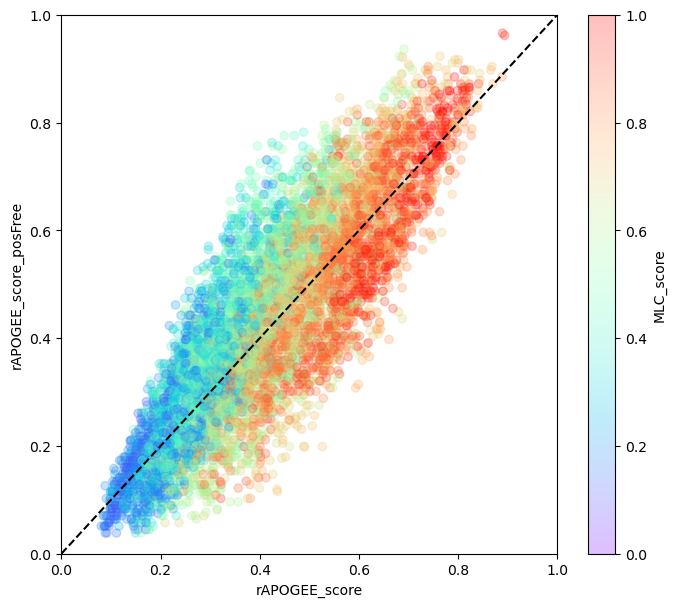

In [18]:
plt.figure(figsize=(8,7))
plt.scatter(
    rapogee_predictions.rAPOGEE_score.values,
    rapogee_predictions.rAPOGEE_score_posFree,
    alpha=.25, c=mithril_features.MLC_score,
    cmap="rainbow", vmin=0, vmax=1
)
plt.xlabel("rAPOGEE_score")
plt.ylabel("rAPOGEE_score_posFree")
plt.colorbar(label="MLC_score")
plt.plot([0,1],[0,1],"k--")
plt.xlim(0,1)
plt.ylim(0,1)
plt.show()

In [19]:
mithril_df = pd.read_csv(
    "../data/mithril_V053.txt",
    sep="\t", low_memory=False, index_col="Mithril_id", na_values="."
)
mithril_df = mithril_df.loc[mithril_df["Molecule_type"]=="rRNA"]
mithril_df = mithril_df.loc[:,~(mithril_df.isna().all())]
mithril_df["gene"] = mithril_df.Gene_symbol.str.replace("-", "")
mithril_df["Gene_position"] = mithril_df["Gene_position"].astype(int)


################################# FIX #################################
# fix for the missing base in mithril variants collection.
# we remove the affected variants from mithril and adjust the Gene_position according to this change

ghost_positions = mithril_df.loc[mithril_df.Ref=="N", ["gene", "Gene_position"]]
display(ghost_positions)
for ghost_id, ghost in ghost_positions.drop_duplicates().iterrows(): # it's just one position
    mithril_df.loc[(mithril_df.gene==ghost.gene) & (mithril_df.Gene_position>ghost.Gene_position), "Gene_position"] -= 1
mithril_df.drop(ghost_positions.index, axis=0, inplace=True)
del ghost_id, ghost, ghost_positions

mithril_df

,gene,Gene_position
Mithril_id,,
MITHRIL.9318,MTRNR2,1437
MITHRIL.9319,MTRNR2,1437
MITHRIL.9320,MTRNR2,1437
MITHRIL.9321,MTRNR2,1437


,Start,Ref,Alt,Molecule_type,Gene_symbol,Extended_annotation,Gene_position,Gene_start,Gene_end,Gene_strand,MLC_score,PhastCons_100V,PhyloP_100V,gene
Mithril_id,,,,,,,,,,,,,,
MITHRIL.1941,648,A,C,rRNA,MT-RNR1,mitochondrially encoded 12S rRNA,1,648,1601,+,0.519343,0.016,-1.211,MTRNR1
MITHRIL.1942,648,A,G,rRNA,MT-RNR1,mitochondrially encoded 12S rRNA,1,648,1601,+,0.519343,0.016,-1.211,MTRNR1
MITHRIL.1943,648,A,T,rRNA,MT-RNR1,mitochondrially encoded 12S rRNA,1,648,1601,+,0.519343,0.016,-1.211,MTRNR1
MITHRIL.1944,649,A,C,rRNA,MT-RNR1,mitochondrially encoded 12S rRNA,2,648,1601,+,0.536906,0.984,8.630,MTRNR1
MITHRIL.1945,649,A,G,rRNA,MT-RNR1,mitochondrially encoded 12S rRNA,2,648,1601,+,0.536906,0.984,8.630,MTRNR1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MITHRIL.9683,3228,T,C,rRNA,MT-RNR2,mitochondrially encoded 16S rRNA,1557,1671,3229,+,0.681815,0.000,-1.952,MTRNR2
MITHRIL.9684,3228,T,G,rRNA,MT-RNR2,mitochondrially encoded 16S rRNA,1557,1671,3229,+,0.681815,0.000,-1.952,MTRNR2
MITHRIL.9685,3229,T,A,rRNA,MT-RNR2,mitochondrially encoded 16S rRNA,1558,1671,3229,+,0.709337,0.000,-0.833,MTRNR2


In [20]:
coord = mithril_features[["x_coord", "y_coord", "z_coord"]]
coord

,x_coord,y_coord,z_coord
Mithril_id,,,
MITHRIL.1941,74.989870,3.792304,-17.815130
MITHRIL.1942,74.989870,3.792304,-17.815130
MITHRIL.1943,74.989870,3.792304,-17.815130
MITHRIL.1944,78.754455,2.011318,-16.298545
MITHRIL.1945,78.754455,2.011318,-16.298545
...,...,...,...
MITHRIL.9683,-39.321650,77.760650,-31.156100
MITHRIL.9684,-39.321650,77.760650,-31.156100
MITHRIL.9685,-31.769100,74.606700,-33.021850


In [21]:
distance_matrix = np.sqrt(
    ((coord.values[:,None]-coord.values)**2).sum(axis=2)
)
distance_matrix.shape

(7536, 7536)

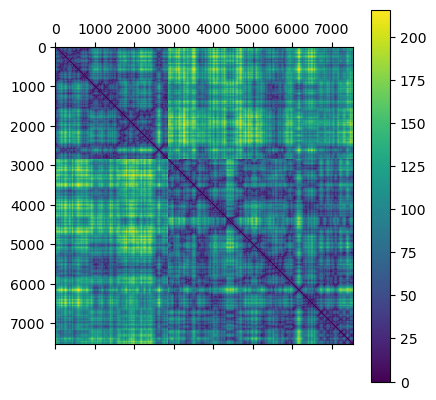

In [22]:
plt.matshow(distance_matrix)
plt.colorbar()

Text(0, 0.5, 'similarity')

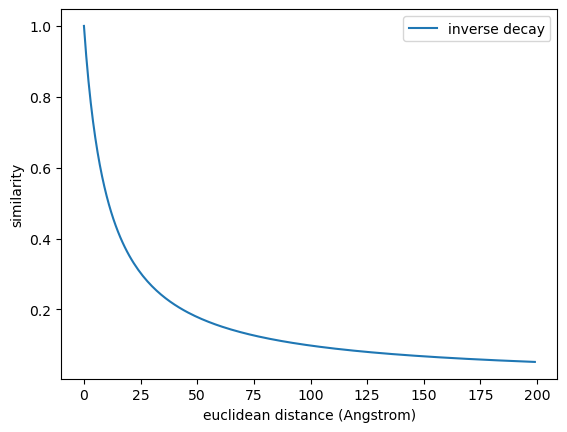

In [23]:
# 10.85 Angstrom is the nucleotide-nucleotide distance in an ideal A-for helix
plt.plot(
    np.arange(200),
    10.85/(10.85+np.arange(200)),
    label="inverse decay"
)
plt.legend()
plt.xlabel("euclidean distance (Angstrom)")
plt.ylabel("similarity")

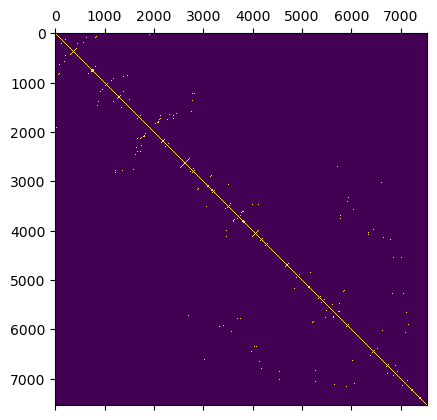

In [24]:
plt.matshow(distance_matrix<=10.85)

In [25]:
similarity_matrix = 10.85/(10.85+distance_matrix)
similarity_matrix.shape

(7536, 7536)

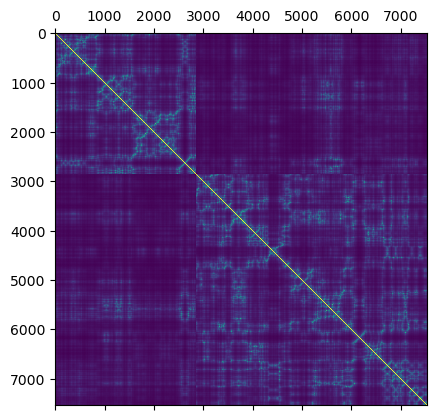

In [26]:
plt.matshow(similarity_matrix)

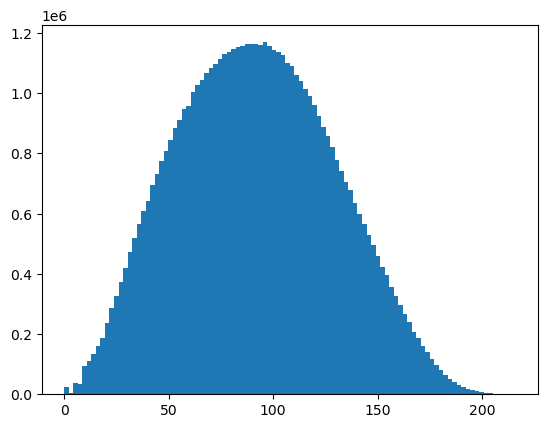

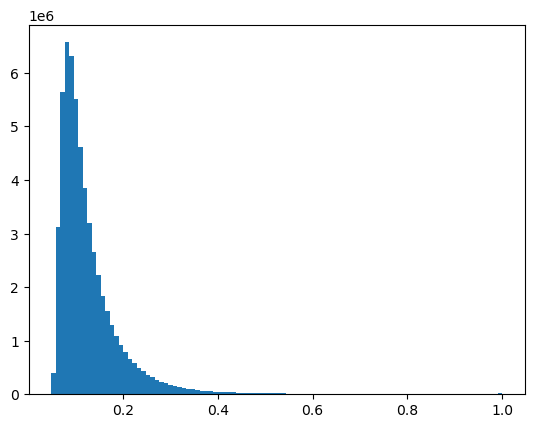

In [27]:
plt.hist(distance_matrix.flatten(), bins=100)
plt.show()
plt.hist(similarity_matrix.flatten(), bins=100)
plt.show()

In [28]:
def lisa(y, W, row_normalize=False, return_pvalue=False, adjust_pvalues=False, n_permutations=1000):
    z = np.array((y-y.mean())/y.std())
    if row_normalize:
        W = W/W.sum(axis=1)[:,None]
    W = W/W.sum()
    l = z@W*z

    if return_pvalue:
        permutations = np.array([
            lisa(np.random.permutation(y), W, row_normalize=row_normalize, return_pvalue=False)
            for _ in range(n_permutations)
        ])
        p_values = np.c_[np.mean(permutations >= l, axis=0), np.mean(permutations <= l, axis=0)].min(axis=1)*2
        if adjust_pvalues:
            p_values = p_adjust_bh(p_values)
        return l, p_values
    return l

In [29]:
# this is huge, and takes hours to run

l, p = lisa(
    rapogee_predictions.rAPOGEE_score_posFree.values, similarity_matrix,
    row_normalize=True, return_pvalue=True, n_permutations=10_000, adjust_pvalues=True
)
l.shape, p.shape

((7536,), (7536,))

/tmp/ipykernel_1553111/4194170451.py:2: RuntimeWarning: divide by zero encountered in log10
  l, -np.log10(p), alpha=.1


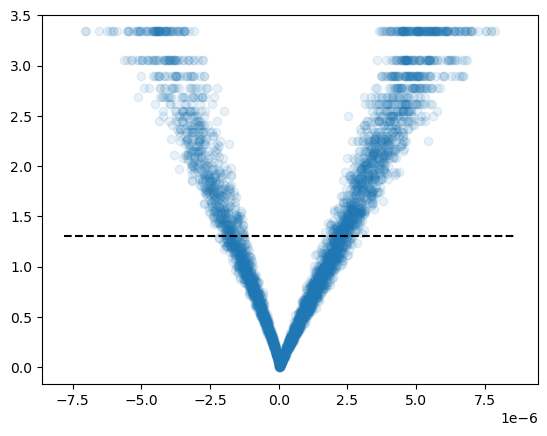

In [30]:
plt.scatter(
    l, -np.log10(p), alpha=.1
)
plt.hlines(-np.log10(.05), *plt.xlim(), linestyle="--", color="k")

In [31]:
lisa_df = rapogee_predictions[["Start", "Ref", "Alt", "Gene_symbol", "Gene_position"]].copy()
lisa_df["lisa"] = l
lisa_df["p_value"] = p
lisa_df

,Start,Ref,Alt,Gene_symbol,Gene_position,lisa,p_value
Mithril_id,,,,,,,
MITHRIL.1941,648,A,C,MT-RNR1,1,-1.094027e-06,0.145748
MITHRIL.1942,648,A,G,MT-RNR1,1,-1.645560e-06,0.068364
MITHRIL.1943,648,A,T,MT-RNR1,1,-1.273875e-06,0.113720
MITHRIL.1944,649,A,C,MT-RNR1,2,-7.648263e-08,0.742424
MITHRIL.1945,649,A,G,MT-RNR1,2,-4.007128e-07,0.418350
...,...,...,...,...,...,...,...
MITHRIL.9683,3228,T,C,MT-RNR2,1558,1.052163e-05,0.000000
MITHRIL.9684,3228,T,G,MT-RNR2,1558,3.916292e-06,0.000456
MITHRIL.9685,3229,T,A,MT-RNR2,1559,-1.307500e-06,0.038598


In [32]:
lisa_coord = rapogee_predictions.join(coord).reset_index().groupby(["Gene_symbol", "Gene_position"])[["x_coord", "y_coord", "z_coord", "Mithril_id"]].first()
lisa_coord = lisa_coord.join(lisa_df.groupby(["Gene_symbol", "Gene_position"]).lisa.sum())
lisa_coord = lisa_coord.join(lisa_df.groupby(["Gene_symbol", "Gene_position"]).p_value.max())
lisa_coord = lisa_coord.join(rapogee_predictions.groupby(["Gene_symbol", "Gene_position"]).rAPOGEE_score_posFree.mean())
lisa_coord

x_coord    y_coord    z_coord    Mithril_id  \
Gene_symbol Gene_position                                                  
MT-RNR1     1              74.989870   3.792304 -17.815130  MITHRIL.1941   
            2              78.754455   2.011318 -16.298545  MITHRIL.1944   
            3              85.081400   0.817800 -16.398700  MITHRIL.1947   
            4              80.692545  -0.982182 -11.784409  MITHRIL.1950   
            5              78.440043  -2.044522  -7.095739  MITHRIL.1953   
...                              ...        ...        ...           ...   
MT-RNR2     1555          -37.469870  65.134652 -21.729174  MITHRIL.9673   
            1556          -37.557696  68.116522 -25.399391  MITHRIL.9676   
            1557          -39.265900  70.391950 -28.928650  MITHRIL.9679   
            1558          -39.321650  77.760650 -31.156100  MITHRIL.9682   
            1559          -31.769100  74.606700 -33.021850  MITHRIL.9685   

                                   lisa   p_value  rAPOGEE_score_posFree  
Gene_symbol Gene_position                                                 
MT-RNR1     1             -4.013462e-06  0.145748               0.193732  
            2             -6.077164e-07  0.742424               0.408120  
            3             -4.640951e-06  0.065403               0.187322  
            4             -4.177625e-06  0.114244               0.348291  
            5             -1.546969e-05  0.000878               0.243590  
...                                 ...       ...                    ...  
MT-RNR2     1555          -4.897423e-06  0.222451               0.474359  
            1556           5.724944e-07  0.037257               0.427350  
            1557           1.082586e-05  0.098477               0.344017  
            1558           2.038663e-05  0.000456               0.260684  
            1559          -2.751884e-06  0.912529               0.457265  

[2512 rows x 7 columns]

In [33]:
lisa_coord.to_csv("../checkpoints/lisa.csv", sep="\t")

In [34]:
### checkpoint ###
lisa_coord = pd.read_csv("../checkpoints/lisa.csv", sep="\t", index_col=["Gene_symbol", "Gene_position"])
lisa_coord

x_coord    y_coord    z_coord    Mithril_id  \
Gene_symbol Gene_position                                                  
MT-RNR1     1              74.989870   3.792304 -17.815130  MITHRIL.1941   
            2              78.754455   2.011318 -16.298545  MITHRIL.1944   
            3              85.081400   0.817800 -16.398700  MITHRIL.1947   
            4              80.692545  -0.982182 -11.784409  MITHRIL.1950   
            5              78.440043  -2.044522  -7.095739  MITHRIL.1953   
...                              ...        ...        ...           ...   
MT-RNR2     1555          -37.469870  65.134652 -21.729174  MITHRIL.9673   
            1556          -37.557696  68.116522 -25.399391  MITHRIL.9676   
            1557          -39.265900  70.391950 -28.928650  MITHRIL.9679   
            1558          -39.321650  77.760650 -31.156100  MITHRIL.9682   
            1559          -31.769100  74.606700 -33.021850  MITHRIL.9685   

                                   lisa   p_value  rAPOGEE_score_posFree  
Gene_symbol Gene_position                                                 
MT-RNR1     1             -4.013462e-06  0.145748               0.193732  
            2             -6.077164e-07  0.742424               0.408120  
            3             -4.640951e-06  0.065403               0.187322  
            4             -4.177625e-06  0.114244               0.348291  
            5             -1.546969e-05  0.000878               0.243590  
...                                 ...       ...                    ...  
MT-RNR2     1555          -4.897423e-06  0.222451               0.474359  
            1556           5.724944e-07  0.037257               0.427350  
            1557           1.082586e-05  0.098477               0.344017  
            1558           2.038663e-05  0.000456               0.260684  
            1559          -2.751884e-06  0.912529               0.457265  

[2512 rows x 7 columns]

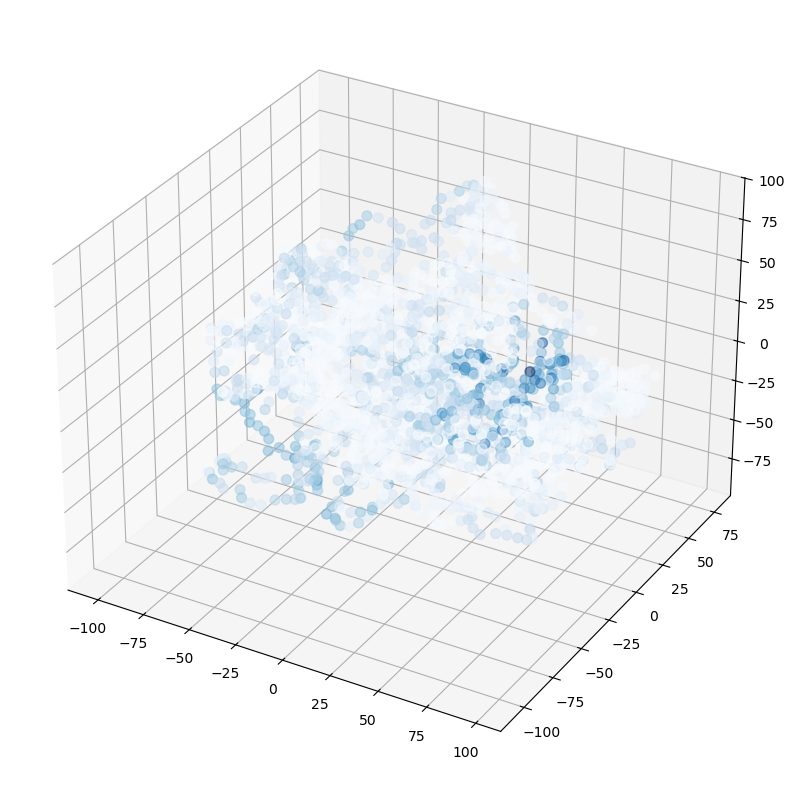

In [35]:
plt.figure(figsize=(10,10))
ax = plt.subplot(projection="3d")
ax.scatter(
    lisa_coord.x_coord, lisa_coord.y_coord, lisa_coord.z_coord,
    c=lisa_coord.lisa, cmap="Blues", s=50, vmin=0, alpha=.5
)
plt.show()

In [36]:
lisa_coord.query("p_value<.05").query("lisa>0")

x_coord    y_coord    z_coord    Mithril_id  \
Gene_symbol Gene_position                                                  
MT-RNR1     8              67.507850 -10.971400  -3.373300  MITHRIL.1962   
            12             74.400450 -19.323250  -3.874900  MITHRIL.1974   
            13             74.755100 -18.060600  -8.605000  MITHRIL.1977   
            20             73.754550   5.482650  -5.744400  MITHRIL.1998   
            22             79.659650  11.749900  -9.673100  MITHRIL.2004   
...                              ...        ...        ...           ...   
MT-RNR2     1551          -40.721682  49.310227 -21.389591  MITHRIL.9661   
            1552          -42.665200  52.765200 -20.798550  MITHRIL.9664   
            1554          -39.336565  61.121609 -19.705217  MITHRIL.9670   
            1556          -37.557696  68.116522 -25.399391  MITHRIL.9676   
            1558          -39.321650  77.760650 -31.156100  MITHRIL.9682   

                                   lisa   p_value  rAPOGEE_score_posFree  
Gene_symbol Gene_position                                                 
MT-RNR1     8              7.691092e-06  0.003533               0.480769  
            12             1.576295e-05  0.005652               0.547009  
            13             2.370584e-06  0.019713               0.455128  
            20             1.218759e-05  0.028181               0.561966  
            22             8.772177e-06  0.038877               0.606125  
...                                 ...       ...                    ...  
MT-RNR2     1551           2.351207e-05  0.000000               0.185897  
            1552           2.895936e-05  0.000000               0.164530  
            1554           5.194444e-06  0.024622               0.386752  
            1556           5.724944e-07  0.037257               0.427350  
            1558           2.038663e-05  0.000456               0.260684  

[1040 rows x 7 columns]

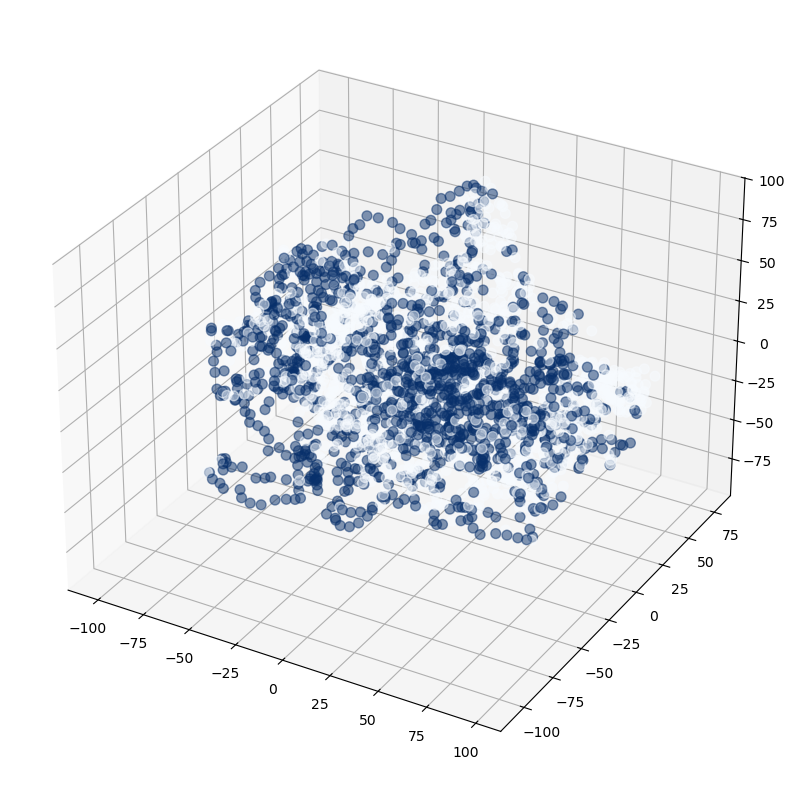

In [37]:
plt.figure(figsize=(10,10))
ax = plt.subplot(projection="3d")
ax.scatter(
    lisa_coord.x_coord, lisa_coord.y_coord, lisa_coord.z_coord,
    c=lisa_coord.p_value<.05, cmap="Blues", s=50, vmin=0, alpha=.5
)
plt.show()

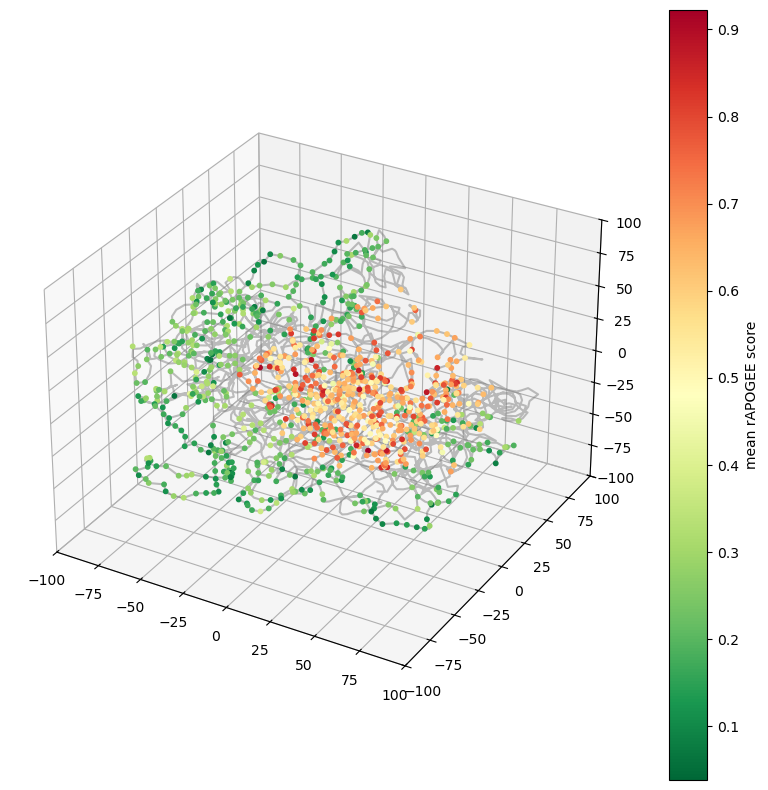

In [38]:
plt.figure(figsize=(10,10))
ax = plt.subplot(projection="3d")

ax.plot(
    lisa_coord.loc["MT-RNR1"].x_coord, lisa_coord.loc["MT-RNR1"].y_coord, lisa_coord.loc["MT-RNR1"].z_coord,
    color="grey", alpha=.5
)

ax.plot(
    lisa_coord.loc["MT-RNR2"].x_coord, lisa_coord.loc["MT-RNR2"].y_coord, lisa_coord.loc["MT-RNR2"].z_coord,
    color="grey", alpha=.5
)

scatter = ax.scatter(
    lisa_coord.loc[(lisa_coord.p_value<.05)&(lisa_coord.lisa>0)].x_coord, lisa_coord.loc[(lisa_coord.p_value<.05)&(lisa_coord.lisa>0)].y_coord, lisa_coord.loc[(lisa_coord.p_value<.05)&(lisa_coord.lisa>0)].z_coord,
    c=lisa_coord.loc[(lisa_coord.p_value<.05)&(lisa_coord.lisa>0)].rAPOGEE_score_posFree, alpha=1, cmap="RdYlGn_r", s=10, # vmin=0, vmax=1,
)
plt.colorbar(scatter, label="mean rAPOGEE score")
ax.set_xlim3d(-100, 100)
ax.set_ylim3d(-100, 100)
ax.set_zlim3d(-100, 100)
plt.savefig("../../figures/svg/robosome_scatter.svg")
plt.show()

In [39]:
lisa_coord.loc[(lisa_coord.lisa>0) & (lisa_coord.p_value<.05), "rAPOGEE_score_posFree"].min(), lisa_coord.loc[(lisa_coord.lisa>0) & (lisa_coord.p_value<.05), "rAPOGEE_score_posFree"].max()

(np.float64(0.0384615384615384), np.float64(0.9223646723646725))

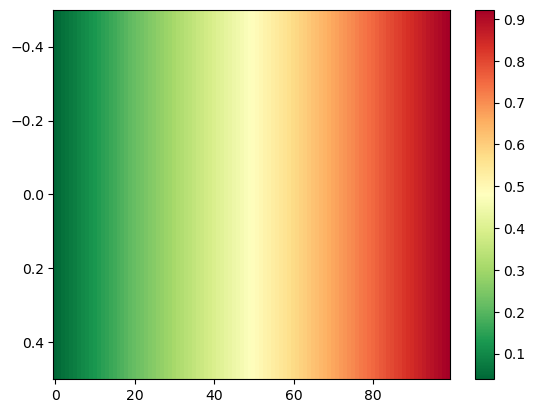

In [40]:
plt.imshow(
    np.linspace(
        lisa_coord.loc[(lisa_coord.lisa>0) & (lisa_coord.p_value<.05), "rAPOGEE_score_posFree"].min(),
        lisa_coord.loc[(lisa_coord.lisa>0) & (lisa_coord.p_value<.05), "rAPOGEE_score_posFree"].max(),
        100
    )[None,:],
    aspect="auto", cmap="RdYlGn_r"
)
plt.colorbar()

In [41]:
def moransI(y, W, row_normalize=False, return_pvalue=False, n_permutations=1000):
    z = np.array((y-y.mean())/y.std())
    if row_normalize:
        W = W/W.sum(axis=1)[:,None]
    W = W/W.sum()
    I = z@W@z
    if return_pvalue:
        permutations = np.array([
            moransI(np.random.permutation(y), W, row_normalize=row_normalize, return_pvalue=False)
            for _ in range(n_permutations)
        ])
        p_value = min(np.sum(permutations >= I), np.sum(permutations <= I)) * 2 / n_permutations
        return I, p_value
    else:
        return I

In [42]:
moransI(
    rapogee_predictions.rAPOGEE_score_posFree.values, similarity_matrix,
    row_normalize=True, return_pvalue=True, n_permutations=10_000
)

(np.float64(0.031966315330415385), np.float64(0.0))

In [47]:
import nglview as nv

In [48]:
chain_map = {
    'MT-RNR1': 'A',  # update based on your PDB
    'MT-RNR2': 'B'
}

chain_map

{'MT-RNR1': 'A', 'MT-RNR2': 'B'}

In [49]:
discretized_scores = (lisa_coord.rAPOGEE_score_posFree.values*10).astype(int)/10
discretized_scores

array([0.1, 0.4, 0.1, ..., 0.3, 0.2, 0.4])

In [50]:
colors = (plt.cm.RdYlGn_r(discretized_scores)*255)[:,:3].astype(int)
colors

array([[ 25, 151,  79],
       [217, 239, 139],
       [ 25, 151,  79],
       ...,
       [164, 216, 105],
       [102, 189,  99],
       [217, 239, 139]])

In [51]:
lisa_coord["color"] = [tuple(color) for color in colors]
lisa_coord

x_coord    y_coord    z_coord    Mithril_id  \
Gene_symbol Gene_position                                                  
MT-RNR1     1              74.989870   3.792304 -17.815130  MITHRIL.1941   
            2              78.754455   2.011318 -16.298545  MITHRIL.1944   
            3              85.081400   0.817800 -16.398700  MITHRIL.1947   
            4              80.692545  -0.982182 -11.784409  MITHRIL.1950   
            5              78.440043  -2.044522  -7.095739  MITHRIL.1953   
...                              ...        ...        ...           ...   
MT-RNR2     1555          -37.469870  65.134652 -21.729174  MITHRIL.9673   
            1556          -37.557696  68.116522 -25.399391  MITHRIL.9676   
            1557          -39.265900  70.391950 -28.928650  MITHRIL.9679   
            1558          -39.321650  77.760650 -31.156100  MITHRIL.9682   
            1559          -31.769100  74.606700 -33.021850  MITHRIL.9685   

                                   lisa   p_value  rAPOGEE_score_posFree  \
Gene_symbol Gene_position                                                  
MT-RNR1     1             -4.013462e-06  0.145748               0.193732   
            2             -6.077164e-07  0.742424               0.408120   
            3             -4.640951e-06  0.065403               0.187322   
            4             -4.177625e-06  0.114244               0.348291   
            5             -1.546969e-05  0.000878               0.243590   
...                                 ...       ...                    ...   
MT-RNR2     1555          -4.897423e-06  0.222451               0.474359   
            1556           5.724944e-07  0.037257               0.427350   
            1557           1.082586e-05  0.098477               0.344017   
            1558           2.038663e-05  0.000456               0.260684   
            1559          -2.751884e-06  0.912529               0.457265   

                                     color  
Gene_symbol Gene_position                   
MT-RNR1     1                (25, 151, 79)  
            2              (217, 239, 139)  
            3                (25, 151, 79)  
            4              (164, 216, 105)  
            5               (102, 189, 99)  
...                                    ...  
MT-RNR2     1555           (217, 239, 139)  
            1556           (217, 239, 139)  
            1557           (164, 216, 105)  
            1558            (102, 189, 99)  
            1559           (217, 239, 139)  

[2512 rows x 8 columns]

In [52]:
lisa_coord["hex"] = lisa_coord["color"].apply(lambda rgb: '#%02x%02x%02x' % rgb)
lisa_coord

x_coord    y_coord    z_coord    Mithril_id  \
Gene_symbol Gene_position                                                  
MT-RNR1     1              74.989870   3.792304 -17.815130  MITHRIL.1941   
            2              78.754455   2.011318 -16.298545  MITHRIL.1944   
            3              85.081400   0.817800 -16.398700  MITHRIL.1947   
            4              80.692545  -0.982182 -11.784409  MITHRIL.1950   
            5              78.440043  -2.044522  -7.095739  MITHRIL.1953   
...                              ...        ...        ...           ...   
MT-RNR2     1555          -37.469870  65.134652 -21.729174  MITHRIL.9673   
            1556          -37.557696  68.116522 -25.399391  MITHRIL.9676   
            1557          -39.265900  70.391950 -28.928650  MITHRIL.9679   
            1558          -39.321650  77.760650 -31.156100  MITHRIL.9682   
            1559          -31.769100  74.606700 -33.021850  MITHRIL.9685   

                                   lisa   p_value  rAPOGEE_score_posFree  \
Gene_symbol Gene_position                                                  
MT-RNR1     1             -4.013462e-06  0.145748               0.193732   
            2             -6.077164e-07  0.742424               0.408120   
            3             -4.640951e-06  0.065403               0.187322   
            4             -4.177625e-06  0.114244               0.348291   
            5             -1.546969e-05  0.000878               0.243590   
...                                 ...       ...                    ...   
MT-RNR2     1555          -4.897423e-06  0.222451               0.474359   
            1556           5.724944e-07  0.037257               0.427350   
            1557           1.082586e-05  0.098477               0.344017   
            1558           2.038663e-05  0.000456               0.260684   
            1559          -2.751884e-06  0.912529               0.457265   

                                     color      hex  
Gene_symbol Gene_position                            
MT-RNR1     1                (25, 151, 79)  #19974f  
            2              (217, 239, 139)  #d9ef8b  
            3                (25, 151, 79)  #19974f  
            4              (164, 216, 105)  #a4d869  
            5               (102, 189, 99)  #66bd63  
...                                    ...      ...  
MT-RNR2     1555           (217, 239, 139)  #d9ef8b  
            1556           (217, 239, 139)  #d9ef8b  
            1557           (164, 216, 105)  #a4d869  
            1558            (102, 189, 99)  #66bd63  
            1559           (217, 239, 139)  #d9ef8b  

[2512 rows x 9 columns]

In [59]:
view = nv.show_file("../data/structures/alphafold_wt_mt_ribosome.pdb")
view.clear_representations()
# view.add_representation("line", selection="all", color="lightgray", opacity=1.)
# view.add_representation("cartoon", selection="all", color="gray", opacity=.5)
# view.add_representation("ribbon", selection="all", color="black", opacity=1.)
view.add_representation("surface", selection="all", color="lightgray", opacity=0.1, quality="low")
#view.center()
view.layout = {'width': '1600px', 'height': '900px'}
view

NGLWidget(layout=Layout(height='900px', width='1600px'))

In [64]:
from collections import defaultdict
color_groups = defaultdict(list)


for _, row in lisa_coord.iterrows():
    gene, pos = row.name
    chain = chain_map[gene]
    color = row["hex"]
    p = row["p_value"]
    l = row["lisa"]

    if p < 0.05 and l > 0:
        selection = f"{int(pos)} and :{chain}"
        color_groups[color].append(selection)
    

len(color_groups)

10

In [65]:
for color, selections in color_groups.items():
    selection_str = " or ".join(selections)
    view.add_representation("surface", selection=selection_str, color=color, opacity=1., quality="low")


In [66]:
view

NGLWidget(layout=Layout(height='900px', width='1600px'), n_components=1)

In [67]:
import nglview
nglview.write_html('../checkpoints/lisa.html', view)